In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import pandas as pd
%matplotlib inline
plt.style.use('default')

churn_data = pd.read_csv('data/churn.csv')
churn_data = churn_data.drop('RowNumber', axis=1)

Задание:<br>
9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

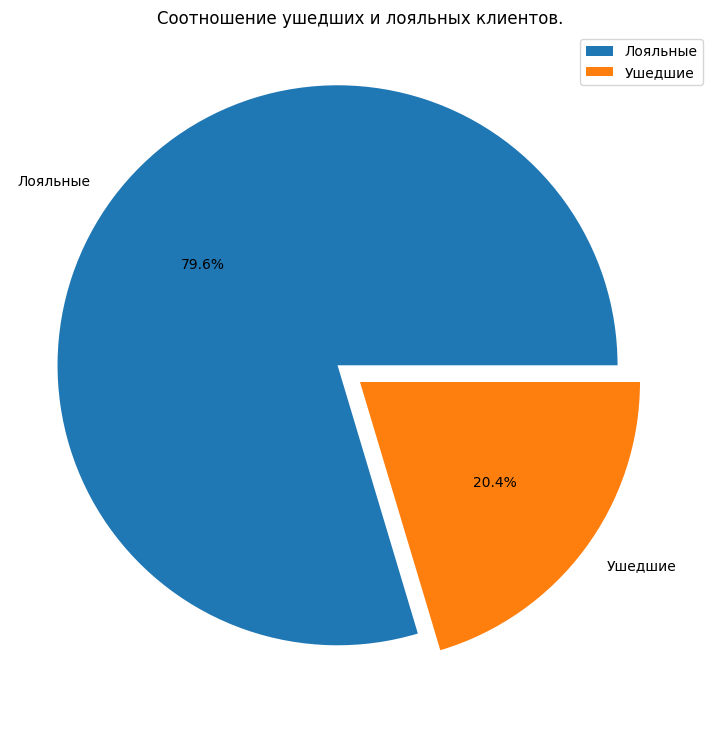

In [2]:
#Подготавливаем данные
churn_data['type_client'] = np.where(churn_data['Exited'] == 1, 'Ушедшие', 'Лояльные')
pie_chart = churn_data.groupby(['type_client'])['CustomerId'].count().copy()
#Строим график
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
plt.title('Cоотношение ушедших и лояльных клиентов.')
axes.pie(pie_chart, 
         explode = [0.1, 0],
         labels = pie_chart.index, 
         autopct='%.1f%%'
         )
axes.legend();


Выводы: <br>
Клиенты в подовляющем большинстве(80%) лояльны к банку. <br>
Банк осуществляет эффективную деятельность по работе с клиентами, но необходимо обратить внимание на значительный отток клиентов и принять меры по уменьшению оттока клиентов. <br>
Банк в целом стабильный, но необходимо понять причины оттока клиентов.

Задание:<br>
9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

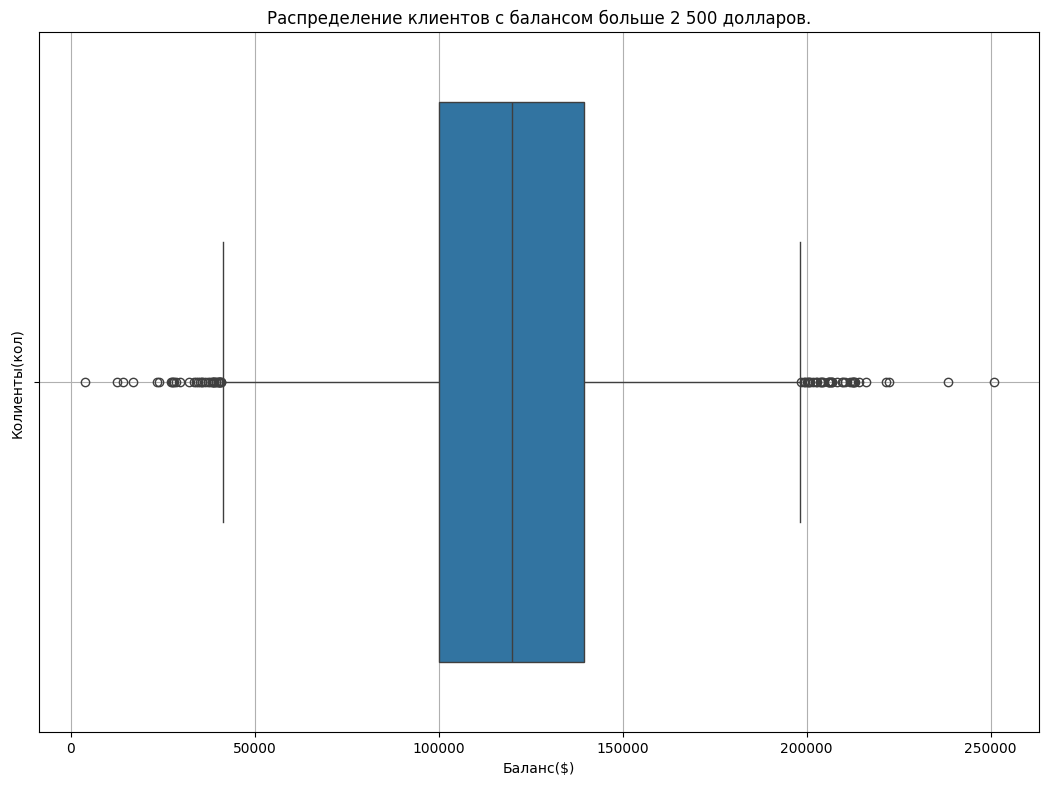

In [3]:
#Подготавливаем данные
boxplot_chart = churn_data.loc[churn_data['Balance'] > 2500, ['Balance']].copy()
#Строим график
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
fig = sns.boxplot(
    data = boxplot_chart,  
    x = "Balance"
)
fig.set_title('Распределение клиентов с балансом больше 2 500 долларов.')
fig.set_xlabel('Баланс($)')
fig.set_ylabel('Колиенты(кол)')
fig.grid();


Выводы:<br>
Из графика видим, клиенты распределены приблизительно от 40 до 198 тысяч долларов. <br>
Медианный баланс приблизительно 120 тысяч долларов, максимальное распределение клиентов в отрезке от 100.2 (25% квантиль) до 140 (75% квантиль) тысяч долларов. <br>
Выбросы слева и справа примерно одинаковой ширины. <br>
Наиболее выгодные условия для клиентов по хранению средств на балансе в банке находятся в интервале от 100 до 140 тысяч долларов.

Задание: <br>
9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

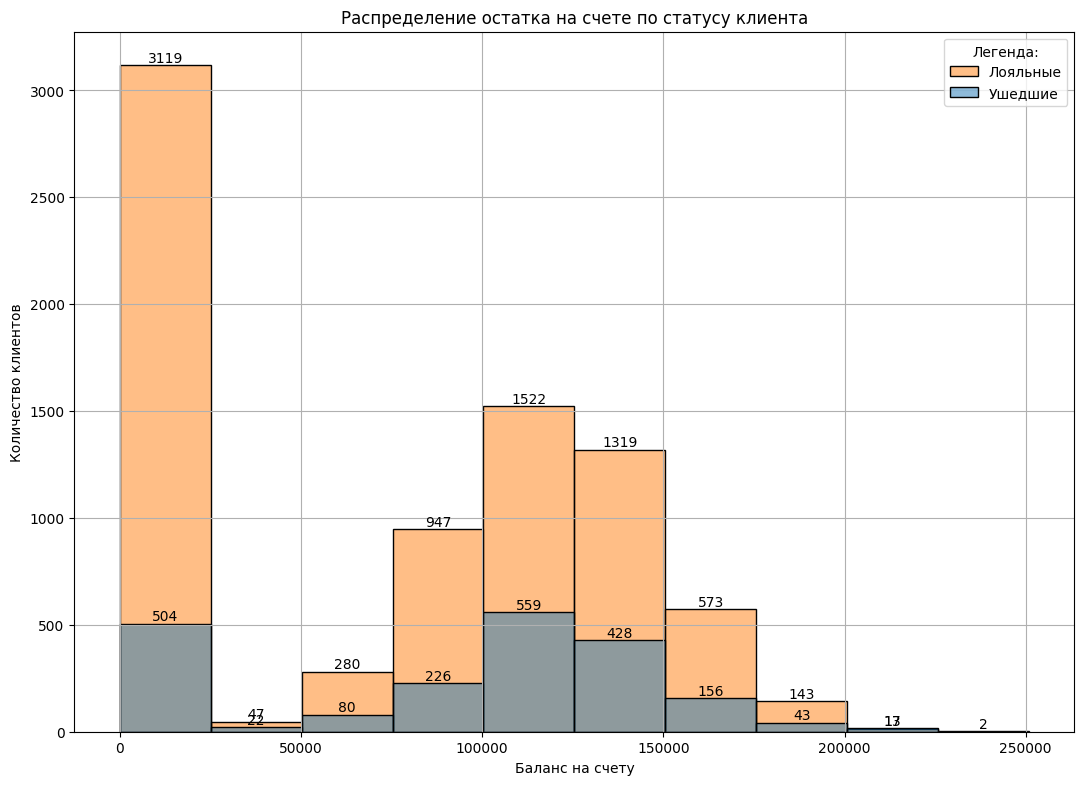

In [4]:
#Строим график
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
fig = sns.histplot(data=churn_data, x='Balance', hue='type_client', bins=10)
for p in fig.patches:
    height = p.get_height()
    if height > 0: 
        fig.text(x = p.get_x() + (p.get_width() / 2), 
                y = height + 0.5,                    
                s = f'{int(height)}',                
                ha = 'center', va = 'bottom')
plt.title("Распределение остатка на счете по статусу клиента")
plt.xlabel("Баланс на счету")
plt.ylabel("Количество клиентов")
plt.legend(labels=['Лояльные','Ушедшие'], title='Легенда:', fontsize=10)
fig.grid()


Выводы: <br>
На графике видно значительное превышение сумм на накопительном счёте лояльных клиентов над ушедшимы. <br>
Не большие суммы на накопительном счёте у ушедших клиентов может быть связано с предварительным выводом средств из банка перед закрытием счёта.<br>
Почти половина лояльных клинетов не хранят денежные стредства на накопительном счёте, возможно это связано с необходимостью осуществлять только разовые платежи через банк.<br>
Ушедших клиентов может не устраивать:
- низкий процент по вкладам
- низкое качество обслуживания (длительные ожидания решения вопросов или проблемы)
- отсутствие или не качественные онлайн-сервисы


Задание: <br>
9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

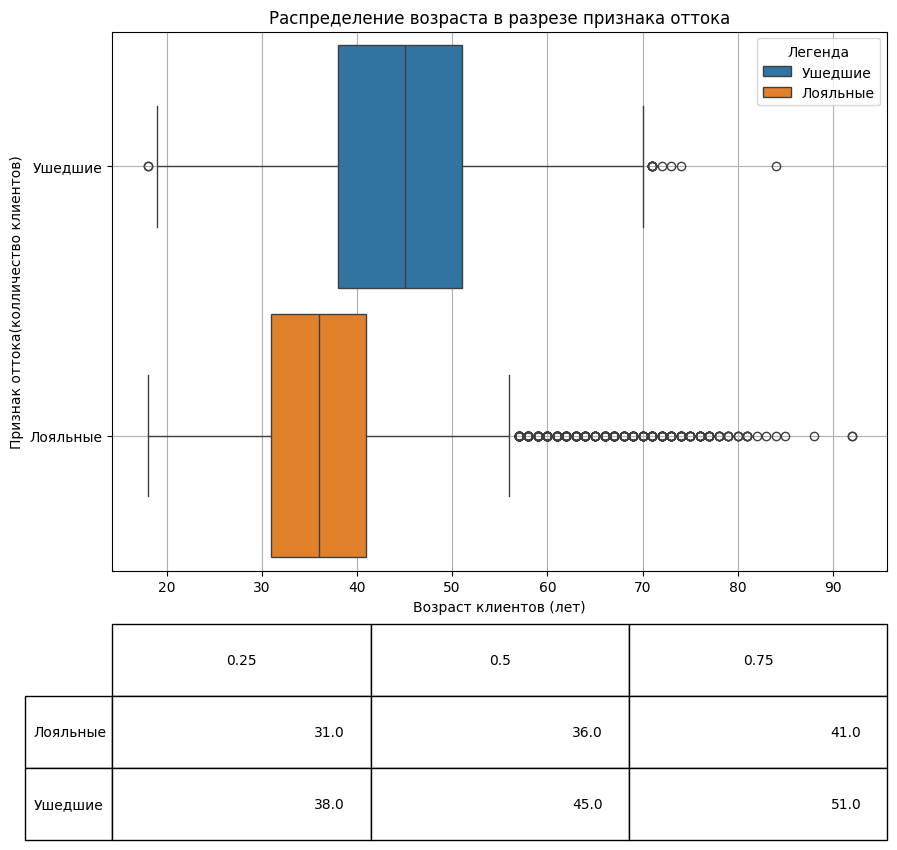

In [5]:
#Подготавливаем данные
df_box = churn_data[['Age','type_client']].copy()
#Строим график
fig = plt.figure(figsize=(10, 7))
boxplot = sns.boxplot(
    data=df_box,
    y='type_client',
    x='Age',
    orient='h',
    width=0.9, 
    hue= 'type_client',
    legend=True
)
# Получаем медианы и квартили
quartiles = df_box.groupby('type_client')['Age'].quantile([.25, .5, .75]).unstack()
# Строим поясняющую таблицу
table = plt.table(
            cellText=quartiles.values,
            rowLabels=quartiles.index,
            colLabels=quartiles.columns,
            bbox=(0, -0.5, 1, 0.4),
            loc='bottom'
          )
boxplot.set_title('Распределение возраста в разрезе признака оттока');
boxplot.set_xlabel('Возраст клиентов (лет)')
boxplot.set_ylabel('Признак оттока(колличество клиентов)')
boxplot.legend(title="Легенда")
boxplot.grid();

 Выводы: <br>
 Из графика видим, наибольший выброс у ушедших клиентов от 38 до 51 года. <br> 
 Медианное значение у ушедших клиентов ровняется 45 лет, диапазон возраста группы клиентов на которые стоит обратить внимание находится от 38 до 51 года.<br>
 Также стоит обратить внимание на группу лояльных клиентов для умешения оттока текущих клиентов в возрасте от 31 до 41 года.<br>
 На графике видно уменьшение возрастной группы лояльных клиентов с 51 года до 41, на данный факт также необходимо обратить внимание.







Задание: <br>
9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.


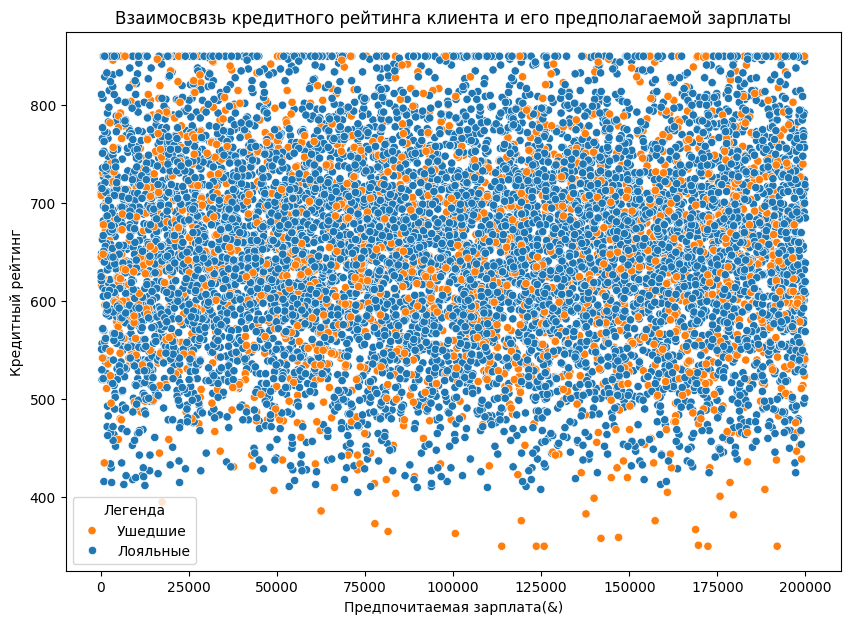

In [6]:
#Строим график
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=churn_data,
    x='EstimatedSalary',
    y='CreditScore',
    hue='Exited'
)
plt.title('Взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты')
plt.xlabel('Предпочитаемая зарплата(&)')
plt.ylabel('Кредитный рейтинг')
plt.legend(title='Легенда',  labels=['Ушедшие', 'Лояльные'])
plt.show()

Выводы: <br>
Точки на графике перемешаны хаотично, можно считать, что кредитный рейтинг и предполагаемая зарплата не оказывают явного влияние на признак оттока клиентов.

Задание: <br>
9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.
Процент ушедших клиентов в каждой группе можно рассчитать как среднее по столбцу Exited (так как 1 — это ушедшие клиенты, а 0 — лояльные, среднее арифметическое по столбцу обозначает долю ушедших клиентов).

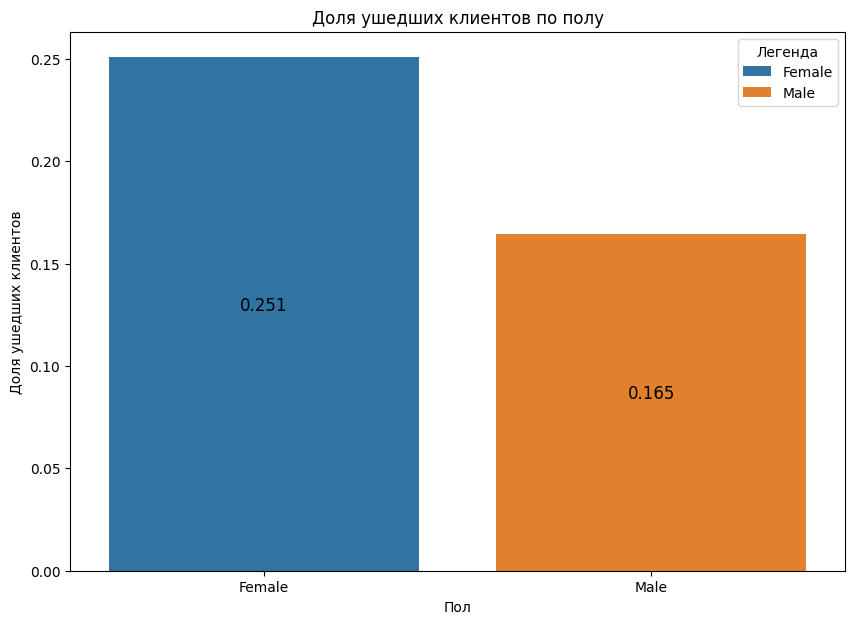

In [7]:
#Подготавливаем данные
df_gender = churn_data.groupby(['Gender'], as_index=False)['Exited'].mean() 
#Строим график
plt.figure(figsize=(10, 7))
fig = sns.barplot(data=df_gender,
            x='Gender', 
            y='Exited',
            hue='Gender',
            legend= 'full' 
            )
for p in fig.patches:
    height = p.get_height()
    if height > 0: 
        fig.text(p.get_x() + p.get_width() / 2., 
                y = height / 2,                    
                s = height.round(3),
                ha='center', va='bottom', fontsize=12)

plt.title('Доля ушедших клиентов по полу')
plt.xlabel('Пол')
plt.ylabel('Доля ушедших клиентов')
plt.legend(title='Легенда')
plt.show()

Выводы: <br>
Из графика видно, что женщины(Famale) уходят из банка чаще мужчин(Male).

Задание: <br>
9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

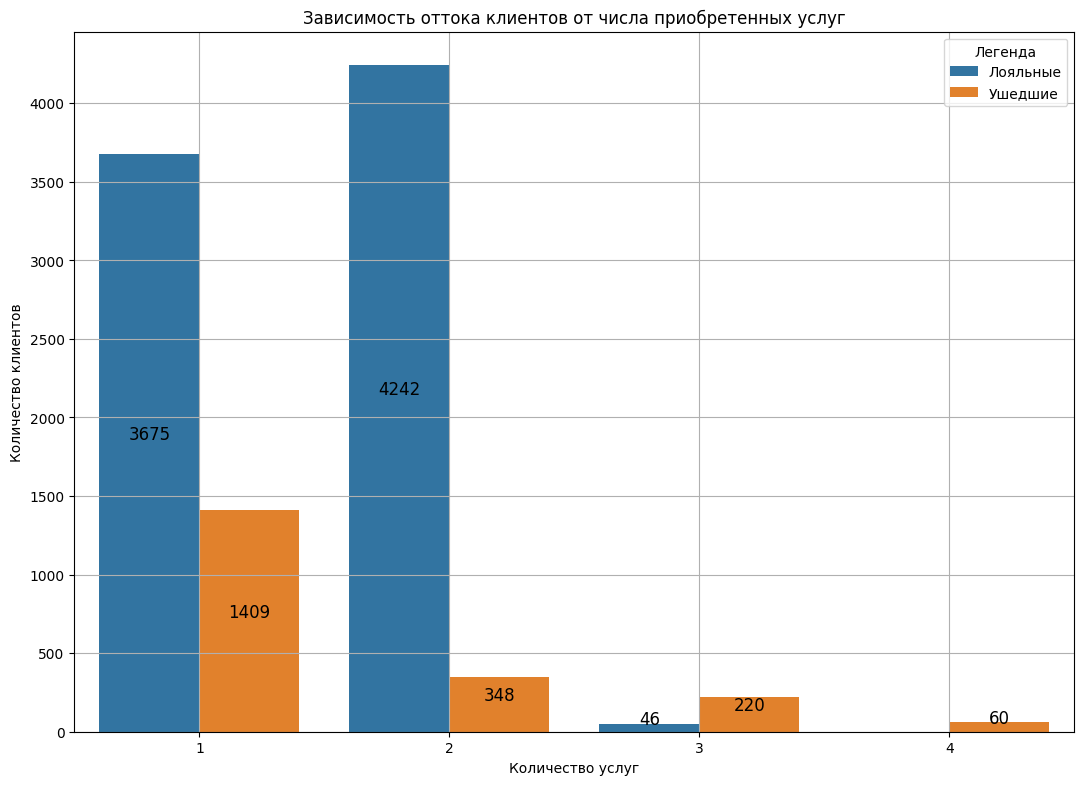

In [8]:
#Подготавливаем данные
df_product = churn_data.groupby(['NumOfProducts','type_client'], as_index=False)['Exited'].count() 
#Строим график
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
fig = sns.barplot(data=df_product,
            x='NumOfProducts', 
            y='Exited',
            hue='type_client'
            )
for p in fig.patches:
    height = p.get_height()
    if height > 0: 
        fig.text(p.get_x() + p.get_width() / 2., 
                y = height / 2,                    
                s = f'{height.round():.0f}',  
                ha='center', va='bottom', fontsize=12) 
plt.title('Зависимость оттока клиентов от числа приобретенных услуг')
plt.xlabel('Количество услуг')
plt.ylabel('Количество клиентов')
plt.legend( title='Легенда')
fig.grid()

Вывод:<br>
На графике видно, что чем больше приобретённых услуг у банка тем меньше лояльных или ушедших клиентов. <br>
Максимальное колличество клиентов обнаружено при приобритении одной или двух услуг у банка. <br>
Банку нужно проанализировать неиспользуемые клиентами услуги и принять меры по разработки стратегии для привлечения клиентов к использованию большим колличеством услуг.

Задание:<br>
9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

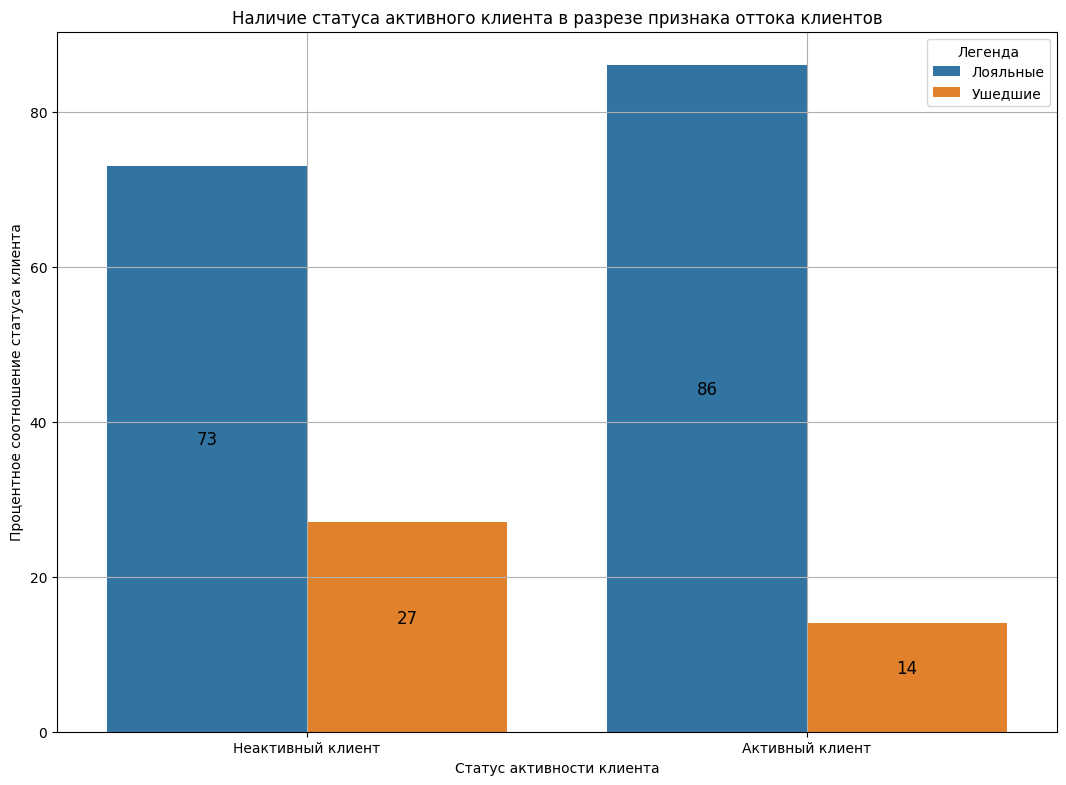

In [9]:
#Подготавливаем данные
df_ActiveMember = churn_data.groupby(['IsActiveMember','type_client'], as_index=False)['Exited'].count() 
df_ActiveMember["sum_itog"] = df_ActiveMember.groupby('IsActiveMember').Exited.transform('sum')
df_ActiveMember["per"] =  ((df_ActiveMember["Exited"] / df_ActiveMember["sum_itog"]) * 100).round()
#Строим график
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
fig = sns.barplot(data=df_ActiveMember,
            x='IsActiveMember', 
            y='per',
            hue='type_client'
            )
for p in fig.patches:
    height = p.get_height()
    if height > 0: 
        fig.text(p.get_x() + p.get_width() / 2., 
                y = height / 2,                    
                s = f'{height.round():.0f}',  
                ha='center', va='bottom', fontsize=12) 
plt.title('Наличие статуса активного клиента в разрезе признака оттока клиентов')
plt.xlabel('Статус активности клиента')
plt.ylabel('Процентное соотношение статуса клиента')
plt.legend( title='Легенда')
plt.xticks(ticks=[0, 1], labels=["Неактивный клиент", "Активный клиент"])
fig.grid()




Вывод:<br>
На графике видно, что среди активных клиентов процент ушедших клиентов значительно ниже.<br>
Среди неактивных клиентов практически треть составляют ушедшие клиенты.<br>
Для уменьшения оттока клиентов рекомендуются следующие шаги:<br>
- провести опрос среди лояльных неактивных клиентов, для разработки более эффективной политики банка;<br>
- персональные предложения неактивным клиентам;<br>
- провести анализ причин отсутствия активности лояльных клиентов.

Задание:<br>
9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

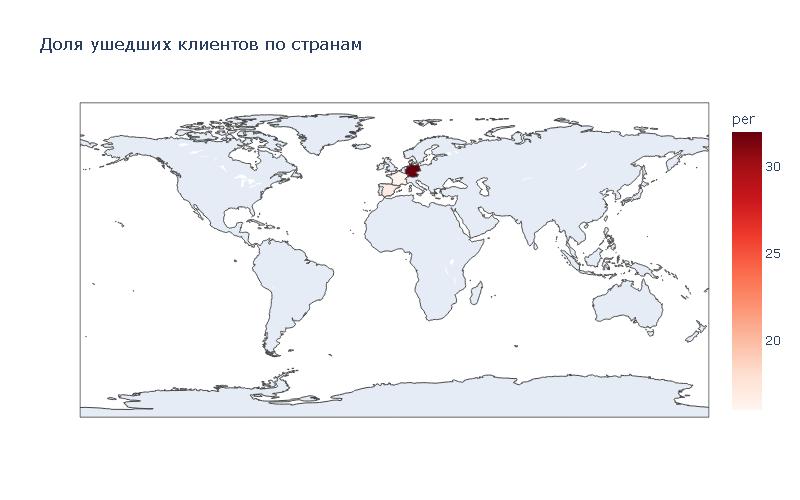

In [13]:
import plotly.express as px
import warnings
import plotly.io as pio
pio.renderers.default = "jupyterlab+png"
warnings.filterwarnings("ignore", category=DeprecationWarning)
#Подготавливаем данные
df_country = churn_data.groupby(['Geography','type_client'], as_index=False)['Exited'].count() 
df_country["sum_itog"] = df_country.groupby('Geography').Exited.transform('sum')
df_country["per"] =  ((df_country["Exited"] / df_country["sum_itog"]) * 100).round()
df_country = df_country.loc[df_country['type_client'] == 'Ушедшие', ['Geography','per']]

# Создаем тепловую картограмму
fig = px.choropleth(df_country,
                    locations="Geography", #столбец с локациями
                    locationmode = "country names", #режим сопоставления локаций с базой Plotly
                    color="per",
                    hover_name="Geography",
                    title="Доля ушедших клиентов по странам",
                    width=800, #ширина
                    height=500, #высота
                    color_continuous_scale='Reds'
                    )
fig.show();


Выводы:<br>
Наибольшая доля ушедших клиентов находится в Германии и составляет 32%.<br>
Наибольшая доля ушедших клиентов может быть связана со следующими предположениями:<br>
- высокой конкуренцией среди банков в данной стране;<br>
- уровнем обслуживания ниже конкурентов;<br>
- не выгодными процентными ставками.

Задание:<br>
9.10. Переведите числовой признак CreditScore в категориальный. Для этого воспользуйтесь функцией get_credit_score_cat(), которая приведена ниже. Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга.
Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat), а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure). В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших пользователей.

На основе полученной сводной таблицы постройте тепловую карту с аннотацией. Найдите на тепловой карте категории клиентов, которые уходят чаще всего.

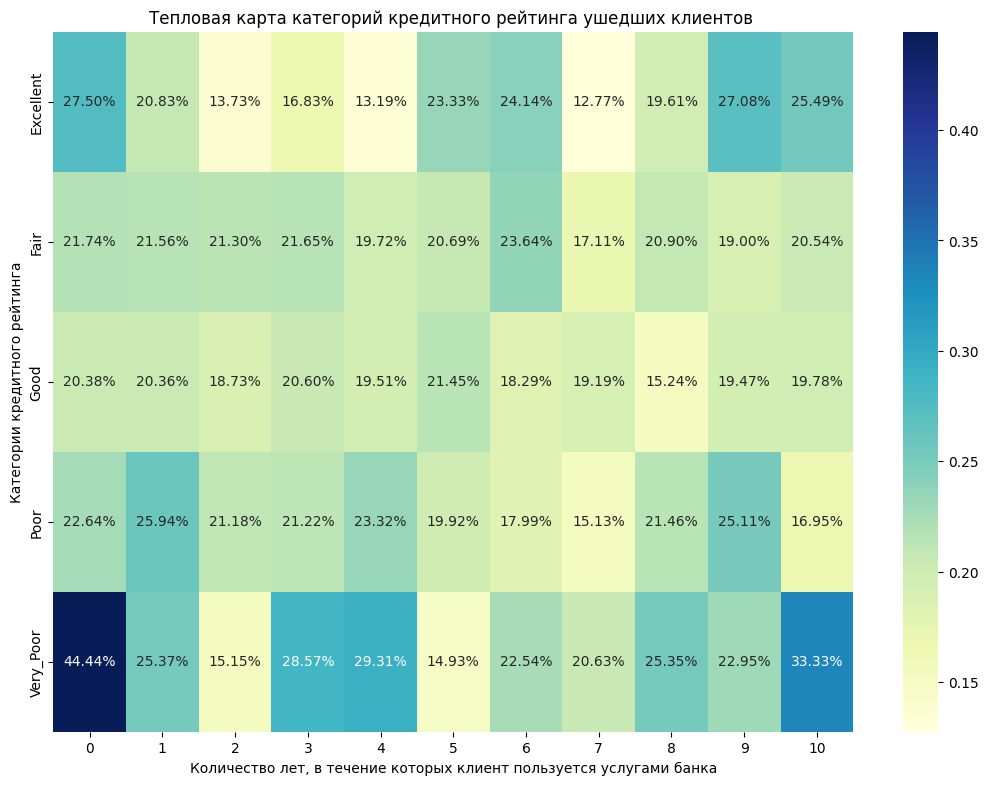

In [ ]:
#Подготавливаем данные
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

df_credit = churn_data.copy()  
df_credit['CreditScoreCat'] = df_credit['CreditScore'].apply(get_credit_score_cat)
df_credit['CreditScoreCat'] = df_credit['CreditScoreCat'].astype('category')
df_credit['Tenure'] = df_credit['Tenure'].astype('category')
#Построение сводной таблицы
df_credit_itog = df_credit.pivot_table(
    values='Exited',
    index=['CreditScoreCat'],
    columns=['Tenure'],
    fill_value=0,
    observed=False
)
#Строим график
heatmap = plt.figure(figsize=(10, 7))
axes = heatmap.add_axes([0, 0, 1, 1])
heatmap = sns.heatmap(data=df_credit_itog, cmap='YlGnBu', annot=True,fmt=".2%")
plt.title("Тепловая карта категорий кредитного рейтинга ушедших клиентов ")
plt.xlabel("Количество лет, в течение которых клиент пользуется услугами банка")
plt.ylabel("Категории кредитного рейтинга")
plt.show();
    

Выводы:<br>
На основе тепловой карты, можем сделать вывод, что чаще всего клиенты уходили с кредитным рейтингом "Very_Poor". <br>
44% клиентов с кредитным рейтингом "Very_Poor" ушло в течении первого года.<br>
Банку необходимо сосредоточить усилия по удержанию клиентов с рейтингом "Very_Poor", используя следующие рекомендации:<br>
- предложить льготное кредитование;<br>
- персональные предложения различных услуг.